In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import math
from sklearn.preprocessing import LabelEncoder

# --- 数据准备（和上周一样）---
df = pd.read_csv("../data/personal_transactions.csv")
df = df[df["Transaction Type"] == "debit"].copy()
df = df[~df["Category"].isin(["Credit Card Payment", "Paycheck"])].copy()

category_map = {
    "Restaurants": "食饮", "Coffee Shops": "食饮", "Alcohol & Bars": "食饮",
    "Fast Food": "食饮", "Food & Dining": "食饮", "Groceries": "食饮",
    "Shopping": "购物", "Electronics & Software": "购物",
    "Home Improvement": "购物", "Haircut": "购物",
    "Gas & Fuel": "出行", "Auto Insurance": "出行",
    "Utilities": "居家", "Mortgage & Rent": "居家",
    "Internet": "居家", "Mobile Phone": "居家",
    "Movies & DVDs": "娱乐", "Music": "娱乐",
    "Television": "娱乐", "Entertainment": "娱乐",
}
df["label"] = df["Category"].map(category_map)
df["Date"] = pd.to_datetime(df["Date"])
df["day_of_week"] = df["Date"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(float)
df["amount_log"] = df["Amount"].apply(lambda x: math.log1p(x))

desc_encoder = LabelEncoder()
df["desc_id"] = desc_encoder.fit_transform(df["Description"])
label_encoder = LabelEncoder()
df["label_id"] = label_encoder.fit_transform(df["label"])

X_num = torch.tensor(df[["amount_log", "day_of_week", "is_weekend"]].values, dtype=torch.float32)
X_desc = torch.tensor(df["desc_id"].values, dtype=torch.long)
y = torch.tensor(df["label_id"].values, dtype=torch.long)

torch.manual_seed(42)
idx = torch.randperm(len(y))
X_num = X_num[idx]
X_desc = X_desc[idx]
y = y[idx]

n_train = int(len(y) * 0.8)
X_num_train, X_num_val   = X_num[:n_train],   X_num[n_train:]
X_desc_train, X_desc_val = X_desc[:n_train],  X_desc[n_train:]
y_train, y_val           = y[:n_train],        y[n_train:]

print("数据准备完成")

数据准备完成


In [3]:
# 把上周的模型定义复制过来
class BillClassifier(nn.Module):
    def __init__(self, n_desc, embed_dim, n_num_features, n_classes):
        super().__init__()
        self.embedding = nn.Embedding(n_desc, embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim + n_num_features, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, n_classes)
        )
    def forward(self, x_desc, x_num):
        emb = self.embedding(x_desc)
        x = torch.cat([emb, x_num], dim=1)
        return self.mlp(x)

# 加载上周保存的权重
clf = BillClassifier(n_desc=63, embed_dim=8, n_num_features=3, n_classes=5)
clf.load_state_dict(torch.load("../data/bill_classifier.pth"))
clf.eval()

# 用训练好的 embedding 层提取商家向量
with torch.no_grad():
    emb_all = clf.embedding(X_desc)          # [617, 8]
    X_all = torch.cat([emb_all, X_num], dim=1)  # [617, 11]

print("Embedding 提取完成")
print("X_all shape:", X_all.shape)

Embedding 提取完成
X_all shape: torch.Size([617, 11])


In [4]:
class BillAutoencoder(nn.Module):
    def __init__(self, input_dim=11, latent_dim=4):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.ReLU(),
            nn.Linear(8, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 8),
            nn.ReLU(),
            nn.Linear(8, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def reconstruction_error(self, x):
        x_rec = self.forward(x)
        return F.mse_loss(x_rec, x, reduction="none").mean(dim=1)

# 切分
X_ae_train = X_all[:n_train]
X_ae_val   = X_all[n_train:]

ae = BillAutoencoder(input_dim=11, latent_dim=4)
optimizer_ae = torch.optim.Adam(ae.parameters(), lr=0.01)

for epoch in range(150):
    ae.train()
    loss = F.mse_loss(ae(X_ae_train), X_ae_train)
    optimizer_ae.zero_grad()
    loss.backward()
    optimizer_ae.step()

    if epoch % 30 == 0:
        ae.eval()
        with torch.no_grad():
            val_loss = F.mse_loss(ae(X_ae_val), X_ae_val)
        print(f"Epoch {epoch:3d} | train: {loss.item():.4f} | val: {val_loss.item():.4f}")

Epoch   0 | train: 3.2961 | val: 3.1904
Epoch  30 | train: 1.4128 | val: 1.3160
Epoch  60 | train: 0.6757 | val: 0.7218
Epoch  90 | train: 0.5139 | val: 0.5782
Epoch 120 | train: 0.4143 | val: 0.4702


In [6]:
ae.eval()
with torch.no_grad():
    errors = ae.reconstruction_error(X_all)

# 95分位数作为阈值，最高的5%视为异常
threshold = torch.quantile(errors, 0.95)
print(f"异常阈值: {threshold.item():.4f}")
print(f"误差范围: {errors.min().item():.4f} ~ {errors.max().item():.4f}")

# 找异常
anomaly_idx = (errors > threshold).nonzero().squeeze()

# idx 是打乱时的顺序，用它还原回原始 df 的行号
original_idx = idx[anomaly_idx].tolist()
df_reset = df.reset_index(drop=True)
df_anomaly = df_reset.iloc[original_idx].copy()
df_anomaly["recon_error"] = errors[anomaly_idx].tolist()

# 按误差从大到小排列
df_anomaly = df_anomaly.sort_values("recon_error", ascending=False)
print(f"\n检测到 {len(df_anomaly)} 条异常交易:")
print(df_anomaly[["Date","Description","Amount","label","recon_error"]].to_string())

异常阈值: 0.9611
误差范围: 0.0128 ~ 2.0635

检测到 31 条异常交易:
          Date                Description   Amount label  recon_error
196 2018-07-06               Amazon Video     6.41    娱乐     2.063548
91  2018-04-03               Amazon Video     6.41    娱乐     1.945700
523 2019-06-20    Mike's Construction Co.  9200.00    购物     1.785909
136 2018-05-11    Mike's Construction Co.  8000.00    购物     1.690243
311 2018-11-10                 Food Truck    24.40    食饮     1.675499
72  2018-03-19   Mediterranean Restaurant    36.48    食饮     1.436365
128 2018-05-05                  Bojangles     7.27    食饮     1.400359
97  2018-04-09                    Spotify    10.69    娱乐     1.380719
599 2019-09-09                    Spotify    10.69    娱乐     1.380719
197 2018-07-09                    Spotify    10.69    娱乐     1.380719
33  2018-02-10                  Bojangles    10.66    食饮     1.314511
8   2018-01-09                    Spotify    10.69    娱乐     1.175125
539 2019-07-09                    Spotif

In [7]:
# 看看这些商家在训练集里出现了几次
for name in ["Spotify", "BP", "Internet Service Provider", "Amazon Video"]:
    count = (df["Description"] == name).sum()
    train_count = df.reset_index(drop=True).iloc[idx[:n_train].tolist()]
    train_count = (train_count["Description"] == name).sum()
    print(f"{name:<30} 总出现: {count:3d} 次  训练集: {train_count:3d} 次")

Spotify                        总出现:  21 次  训练集:  15 次
BP                             总出现:  20 次  训练集:  18 次
Internet Service Provider      总出现:  21 次  训练集:  18 次
Amazon Video                   总出现:   2 次  训练集:   0 次


Matplotlib is building the font cache; this may take a moment.
/var/folders/lv/mnjxv0d53_xczbffr49m5z_40000gn/T/ipykernel_28891/1165763769.py:16: UserWarning: Glyph 24322 (\N{CJK UNIFIED IDEOGRAPH-5F02}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/lv/mnjxv0d53_xczbffr49m5z_40000gn/T/ipykernel_28891/1165763769.py:16: UserWarning: Glyph 24120 (\N{CJK UNIFIED IDEOGRAPH-5E38}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/lv/mnjxv0d53_xczbffr49m5z_40000gn/T/ipykernel_28891/1165763769.py:16: UserWarning: Glyph 38408 (\N{CJK UNIFIED IDEOGRAPH-9608}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/lv/mnjxv0d53_xczbffr49m5z_40000gn/T/ipykernel_28891/1165763769.py:16: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/lv/mnjxv0d53_xczbffr49m5z_40000gn/T/ipykernel_28891/1165763769.py:17: UserWarning: Glyph 24322 (\N{CJK UNIFIED IDEOGRAPH-5F02}) missing from

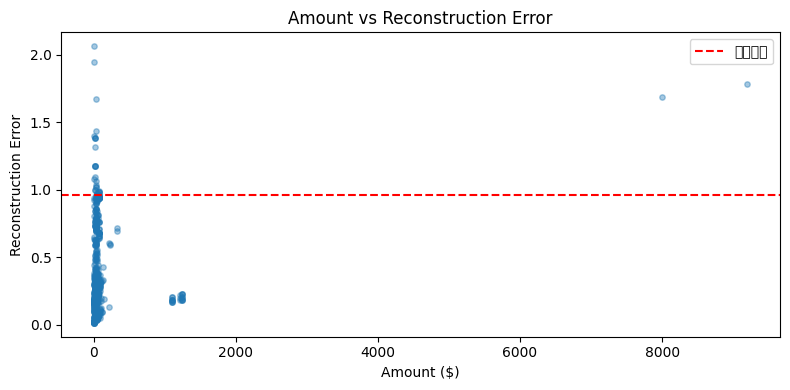

图已保存


In [8]:
import matplotlib.pyplot as plt

ae.eval()
with torch.no_grad():
    errors_all = ae.reconstruction_error(X_all).numpy()

amounts = df.reset_index(drop=True).iloc[idx.tolist()]["Amount"].values

plt.figure(figsize=(8, 4))
plt.scatter(amounts, errors_all, alpha=0.4, s=15)
plt.axhline(y=threshold.item(), color='red', linestyle='--', label='异常阈值')
plt.xlabel("Amount ($)")
plt.ylabel("Reconstruction Error")
plt.title("Amount vs Reconstruction Error")
plt.legend()
plt.tight_layout()
plt.savefig("../data/error_vs_amount.png", dpi=120)
plt.show()
print("图已保存")

In [9]:
# 同时看看 Spotify 的误差分布
spotify_mask = df.reset_index(drop=True).iloc[idx.tolist()]["Description"].values == "Spotify"
spotify_errors = errors_all[spotify_mask]
spotify_amounts = amounts[spotify_mask]

print("Spotify 的统计:")
print(f"  出现次数: {spotify_mask.sum()}")
print(f"  Amount: {spotify_amounts[0]:.2f} (每次都一样吗? {len(set(spotify_amounts)) == 1})")
print(f"  误差范围: {spotify_errors.min():.4f} ~ {spotify_errors.max():.4f}")
print(f"  误差均值: {spotify_errors.mean():.4f}")

# 对比一个正常商家
gs_mask = df.reset_index(drop=True).iloc[idx.tolist()]["Description"].values == "Grocery Store"
gs_errors = errors_all[gs_mask]
print("\nGrocery Store 的统计:")
print(f"  出现次数: {gs_mask.sum()}")
print(f"  误差范围: {gs_errors.min():.4f} ~ {gs_errors.max():.4f}")
print(f"  误差均值: {gs_errors.mean():.4f}")

Spotify 的统计:
  出现次数: 21
  Amount: 10.69 (每次都一样吗? True)
  误差范围: 0.5893 ~ 1.3807
  误差均值: 0.9086

Grocery Store 的统计:
  出现次数: 103
  误差范围: 0.0328 ~ 0.3487
  误差均值: 0.1029


In [10]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# 对 X_all 做标准化（均值0，方差1）
scaler = StandardScaler()
X_all_np = X_all.numpy()
X_all_scaled = torch.tensor(scaler.fit_transform(X_all_np), dtype=torch.float32)

# 保存 scaler，之后推理时要用同一个
import pickle
with open("../data/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# 重新切分
X_ae_train_s = X_all_scaled[:n_train]
X_ae_val_s   = X_all_scaled[n_train:]

# 重新训练
ae2 = BillAutoencoder(input_dim=11, latent_dim=4)
optimizer_ae2 = torch.optim.Adam(ae2.parameters(), lr=0.01)

for epoch in range(150):
    ae2.train()
    loss = F.mse_loss(ae2(X_ae_train_s), X_ae_train_s)
    optimizer_ae2.zero_grad()
    loss.backward()
    optimizer_ae2.step()

    if epoch % 30 == 0:
        ae2.eval()
        with torch.no_grad():
            val_loss = F.mse_loss(ae2(X_ae_val_s), X_ae_val_s)
        print(f"Epoch {epoch:3d} | train: {loss.item():.4f} | val: {val_loss.item():.4f}")

Epoch   0 | train: 1.0551 | val: 1.0543
Epoch  30 | train: 0.6049 | val: 0.6499
Epoch  60 | train: 0.4324 | val: 0.4787
Epoch  90 | train: 0.3058 | val: 0.3494
Epoch 120 | train: 0.2250 | val: 0.2834


In [11]:
ae2.eval()
with torch.no_grad():
    errors2 = ae2.reconstruction_error(X_all_scaled)

threshold2 = torch.quantile(errors2, 0.95)
print(f"新阈值: {threshold2.item():.4f}")
print(f"误差范围: {errors2.min().item():.4f} ~ {errors2.max().item():.4f}")

anomaly_idx2 = (errors2 > threshold2).nonzero().squeeze()
original_idx2 = idx[anomaly_idx2].tolist()
df_anomaly2 = df.reset_index(drop=True).iloc[original_idx2].copy()
df_anomaly2["recon_error"] = errors2[anomaly_idx2].tolist()
df_anomaly2 = df_anomaly2.sort_values("recon_error", ascending=False)

print(f"\n检测到 {len(df_anomaly2)} 条异常交易:")
print(df_anomaly2[["Date","Description","Amount","label","recon_error"]].to_string())

新阈值: 0.5542
误差范围: 0.0107 ~ 2.5717

检测到 31 条异常交易:
          Date                Description   Amount label  recon_error
196 2018-07-06               Amazon Video     6.41    娱乐     2.571742
91  2018-04-03               Amazon Video     6.41    娱乐     2.442189
72  2018-03-19   Mediterranean Restaurant    36.48    食饮     1.264637
529 2019-07-01             Hawaiian Grill    24.97    食饮     1.053622
311 2018-11-10                 Food Truck    24.40    食饮     0.960796
155 2018-05-29              Movie Theater     6.25    娱乐     0.905490
136 2018-05-11    Mike's Construction Co.  8000.00    购物     0.888839
152 2018-05-28              Movie Theater     9.62    娱乐     0.880908
523 2019-06-20    Mike's Construction Co.  9200.00    购物     0.877225
154 2018-05-29              Movie Theater    20.00    娱乐     0.859784
332 2018-11-27              Movie Theater    17.00    娱乐     0.855265
435 2019-03-12               Bakery Place     3.02    食饮     0.827152
190 2018-07-02              Movie Theater

In [12]:
torch.save(ae2.state_dict(), "../data/bill_autoencoder.pth")
print("Autoencoder 已保存")

Autoencoder 已保存


In [13]:
from transformers import AutoTokenizer, AutoModel
import torch

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model_bert = AutoModel.from_pretrained("bert-base-uncased")
model_bert.eval()

# 编码几个商家名，看看语义距离
names = ["Starbucks", "Coffee Shop", "Amazon", "Grocery Store", "Gas Station"]

embeddings = []
for name in names:
    inputs = tokenizer(name, return_tensors="pt")
    with torch.no_grad():
        outputs = model_bert(**inputs)
    # 取 [CLS] token 的向量作为整句表示
    emb = outputs.last_hidden_state[:, 0, :]  # [1, 768]
    embeddings.append(emb.squeeze())

# 计算余弦相似度
import torch.nn.functional as F
emb_matrix = torch.stack(embeddings)  # [5, 768]
emb_norm = F.normalize(emb_matrix, dim=1)
sim_matrix = emb_norm @ emb_norm.T

print("余弦相似度矩阵:")
print(f"{'':>15}", end="")
for name in names:
    print(f"{name:>15}", end="")
print()
for i, name in enumerate(names):
    print(f"{name:>15}", end="")
    for j in range(len(names)):
        print(f"{sim_matrix[i,j].item():>15.3f}", end="")
    print()

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


余弦相似度矩阵:
                     Starbucks    Coffee Shop         Amazon  Grocery Store    Gas Station
      Starbucks          1.000          0.936          0.957          0.878          0.849
    Coffee Shop          0.936          1.000          0.923          0.960          0.906
         Amazon          0.957          0.923          1.000          0.858          0.832
  Grocery Store          0.878          0.960          0.858          1.000          0.932
    Gas Station          0.849          0.906          0.832          0.932          1.000


In [14]:
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn as nn

# --- 提取全部商家名的 BERT embedding，做一次就够了 ---
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert = AutoModel.from_pretrained("bert-base-uncased")
bert.eval()

# 获取所有唯一商家名（按 desc_encoder 的顺序）
desc_names = desc_encoder.classes_.tolist()  # 63个商家名，顺序和 desc_id 对应
print(f"商家数量: {len(desc_names)}")
print(f"前5个: {desc_names[:5]}")

# 批量提取 embedding
bert_embeddings = []
with torch.no_grad():
    for name in desc_names:
        inputs = tokenizer(
            name,
            return_tensors="pt",
            max_length=16,        # 商家名很短，16够用
            truncation=True,
            padding="max_length"
        )
        outputs = bert(**inputs)
        emb = outputs.last_hidden_state[:, 0, :]  # [CLS] token, shape: [1, 768]
        bert_embeddings.append(emb.squeeze())

# 堆成矩阵：[63, 768]
bert_emb_matrix = torch.stack(bert_embeddings)
print(f"\nBERT embedding matrix shape: {bert_emb_matrix.shape}")

# 保存备用
torch.save(bert_emb_matrix, "../data/bert_emb_matrix.pth")
print("已保存")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


商家数量: 63
前5个: ['Amazon', 'Amazon Video', 'American Tavern', 'BBQ Restaurant', 'BP']

BERT embedding matrix shape: torch.Size([63, 768])
已保存


In [15]:
class BillClassifierBERT(nn.Module):
    def __init__(self, bert_emb_matrix, n_num_features, n_classes):
        super().__init__()
        bert_dim = bert_emb_matrix.shape[1]  # 768

        # 把预计算好的 BERT embedding 注册为不可训练的 buffer
        self.register_buffer("bert_emb", bert_emb_matrix)

        # 降维层：768 → 16，这一层是可训练的
        self.proj = nn.Sequential(
            nn.Linear(bert_dim, 16),
            nn.ReLU()
        )

        # 分类头
        self.mlp = nn.Sequential(
            nn.Linear(16 + n_num_features, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, n_classes)
        )

    def forward(self, x_desc, x_num):
        # x_desc 是商家 ID，用它查 BERT embedding 表
        emb = self.bert_emb[x_desc]       # [batch, 768]
        emb = self.proj(emb)              # [batch, 16]
        x = torch.cat([emb, x_num], dim=1)
        return self.mlp(x)

# 训练
model_bert_clf = BillClassifierBERT(
    bert_emb_matrix=bert_emb_matrix,
    n_num_features=3,
    n_classes=5
)

trainable = sum(p.numel() for p in model_bert_clf.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_bert_clf.parameters())
print(f"可训练参数: {trainable}  /  总参数: {total}")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_bert_clf.parameters(), lr=0.01)

for epoch in range(100):
    model_bert_clf.train()
    logits = model_bert_clf(X_desc_train, X_num_train)
    loss = criterion(logits, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        model_bert_clf.eval()
        with torch.no_grad():
            val_logits = model_bert_clf(X_desc_val, X_num_val)
            val_loss = criterion(val_logits, y_val)
            val_acc = (val_logits.argmax(dim=1) == y_val).float().mean()
        print(f"Epoch {epoch:3d} | train loss: {loss.item():.4f} | val loss: {val_loss.item():.4f} | val acc: {val_acc.item():.2f}")

可训练参数: 13109  /  总参数: 13109
Epoch   0 | train loss: 1.7287 | val loss: 1.5472 | val acc: 0.37
Epoch  10 | train loss: 0.9418 | val loss: 0.8430 | val acc: 0.77
Epoch  20 | train loss: 0.4091 | val loss: 0.3904 | val acc: 0.82
Epoch  30 | train loss: 0.1456 | val loss: 0.1951 | val acc: 0.95
Epoch  40 | train loss: 0.0655 | val loss: 0.1717 | val acc: 0.96
Epoch  50 | train loss: 0.0426 | val loss: 0.1660 | val acc: 0.98
Epoch  60 | train loss: 0.0213 | val loss: 0.1851 | val acc: 0.98
Epoch  70 | train loss: 0.0168 | val loss: 0.1951 | val acc: 0.98
Epoch  80 | train loss: 0.0111 | val loss: 0.1961 | val acc: 0.98
Epoch  90 | train loss: 0.0122 | val loss: 0.2053 | val acc: 0.98


In [16]:
torch.save(model_bert_clf.state_dict(), "../data/bill_classifier_bert.pth")
print("BERT 分类器已保存")

BERT 分类器已保存


In [17]:
# 用 BERT 分类器提取特征，重训 Autoencoder
model_bert_clf.eval()
with torch.no_grad():
    emb_bert = model_bert_clf.bert_emb[X_desc]   # [617, 768]
    emb_proj = model_bert_clf.proj(emb_bert)      # [617, 16]
    X_all_bert = torch.cat([emb_proj, X_num], dim=1)  # [617, 19]

print("新特征维度:", X_all_bert.shape)

# 重新标准化（维度变了，旧 scaler 不能用）
from sklearn.preprocessing import StandardScaler
import pickle

scaler_bert = StandardScaler()
X_all_bert_scaled = torch.tensor(
    scaler_bert.fit_transform(X_all_bert.numpy()),
    dtype=torch.float32
)

# 保存新 scaler
with open("../data/scaler_bert.pkl", "wb") as f:
    pickle.dump(scaler_bert, f)

# 切分
X_ae_train_bert = X_all_bert_scaled[:n_train]
X_ae_val_bert   = X_all_bert_scaled[n_train:]

# 重训 Autoencoder，注意 input_dim 现在是 19
ae_bert = BillAutoencoder(input_dim=19, latent_dim=6)
optimizer_ae_bert = torch.optim.Adam(ae_bert.parameters(), lr=0.01)

for epoch in range(150):
    ae_bert.train()
    loss = F.mse_loss(ae_bert(X_ae_train_bert), X_ae_train_bert)
    optimizer_ae_bert.zero_grad()
    loss.backward()
    optimizer_ae_bert.step()

    if epoch % 30 == 0:
        ae_bert.eval()
        with torch.no_grad():
            val_loss = F.mse_loss(ae_bert(X_ae_val_bert), X_ae_val_bert)
        print(f"Epoch {epoch:3d} | train: {loss.item():.4f} | val: {val_loss.item():.4f}")

# 计算新阈值
ae_bert.eval()
with torch.no_grad():
    errors_bert = ae_bert.reconstruction_error(X_all_bert_scaled)

threshold_bert = torch.quantile(errors_bert, 0.95)
print(f"\n新异常阈值: {threshold_bert.item():.4f}")

# 保存
torch.save(ae_bert.state_dict(), "../data/bill_autoencoder_bert.pth")
print("已保存 bill_autoencoder_bert.pth")

Task was destroyed but it is pending!
task: <Task pending name='Task-102' coro=<_async_in_context.<locals>.run_in_context() done, defined at /opt/anaconda3/envs/mlenv/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-103' coro=<Kernel.shell_main() running at /opt/anaconda3/envs/mlenv/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /opt/anaconda3/envs/mlenv/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
/opt/anaconda3/envs/mlenv/lib/python3.11/site-packages/torch/nn/modules/module.py:517: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  super().__setattr__("_forward_pre_hooks_with_kwargs", OrderedDict())
Task was destroyed but it is pending!
task: <Task pending name='Task-103' coro=<Kernel.shell_main() running at /opt/anaconda3/envs/mlenv/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


新特征维度: torch.Size([617, 19])
Epoch   0 | train: 0.4688 | val: 0.6932
Epoch  30 | train: 0.2351 | val: 0.4831
Epoch  60 | train: 0.1119 | val: 0.3790
Epoch  90 | train: 0.0627 | val: 0.3268
Epoch 120 | train: 0.0367 | val: 0.3009

新异常阈值: 0.0598
已保存 bill_autoencoder_bert.pth


In [18]:
import pickle

with open("../data/desc_encoder.pkl", "wb") as f:
    pickle.dump(desc_encoder, f)

with open("../data/label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("Encoders 已保存")
print(f"data/ 目录现在应该有:")
print("  bill_classifier_bert.pth")
print("  bill_autoencoder_bert.pth")
print("  bert_emb_matrix.pth")
print("  scaler_bert.pkl")
print("  desc_encoder.pkl")
print("  label_encoder.pkl")

Encoders 已保存
data/ 目录现在应该有:
  bill_classifier_bert.pth
  bill_autoencoder_bert.pth
  bert_emb_matrix.pth
  scaler_bert.pkl
  desc_encoder.pkl
  label_encoder.pkl


In [19]:
# 在 notebook 里运行，查 Conoco 的原始数据
df_reset = df.reset_index(drop=True)
print(df_reset[df_reset["Description"] == "Conoco"])

          Date Description  Amount Transaction Type    Category Account Name  \
213 2018-07-26      Conoco   33.67            debit  Gas & Fuel  Silver Card   

    label  day_of_week  is_weekend  amount_log  desc_id  label_id  
213    出行            3         0.0    3.545875       18         0  


In [20]:
import math

# 模拟 _preprocess
description = "Conoco"
amount = 33.67
date_str = "2018-07-26"

# 第一步：desc_id
desc_id = desc_encoder.transform(["Conoco"])[0]
print(f"desc_id: {desc_id}")

# 第二步：x_num
date = pd.to_datetime(date_str)
x_num = torch.tensor([[
    math.log1p(amount),
    float(date.dayofweek),
    float(date.dayofweek >= 5)
]], dtype=torch.float32)
print(f"x_num: {x_num}")

# 第三步：提取特征
x_desc = torch.tensor([desc_id], dtype=torch.long)
with torch.no_grad():
    emb_proj = model_bert_clf.proj(model_bert_clf.bert_emb[x_desc])
    x_combined = torch.cat([emb_proj, x_num], dim=1)

print(f"x_combined shape: {x_combined.shape}")
print(f"x_combined: {x_combined}")

# 第四步：标准化
x_scaled = torch.tensor(
    scaler_bert.transform(x_combined.numpy()),
    dtype=torch.float32
)
print(f"x_scaled: {x_scaled}")
print(f"x_scaled 最大值: {x_scaled.abs().max().item():.4f}")

desc_id: 18
x_num: tensor([[3.5459, 3.0000, 0.0000]])
x_combined shape: torch.Size([1, 19])
x_combined: tensor([[0.0000e+00, 9.9760e+00, 0.0000e+00, 8.3610e+00, 9.2167e-04, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 4.0780e+00, 0.0000e+00, 0.0000e+00,
         5.6034e+00, 0.0000e+00, 0.0000e+00, 7.8123e+00, 3.5459e+00, 3.0000e+00,
         0.0000e+00]])
x_scaled: tensor([[ 0.0000,  1.0299,  0.0000,  1.0344, 24.8173,  0.0000,  0.0000,  0.0000,
          0.0000, -0.0928,  0.0000,  0.0000, -0.8213,  0.0000,  0.0000, -0.2457,
          0.1367,  0.2224, -0.5342]])
x_scaled 最大值: 24.8173


In [21]:
# 看第5个维度在训练数据里的分布
dim4 = X_all_bert_scaled[:, 4]
print(f"训练数据第5维:")
print(f"  均值: {dim4.mean().item():.6f}")
print(f"  标准差: {dim4.std().item():.6f}")
print(f"  最小值: {dim4.min().item():.6f}")
print(f"  最大值: {dim4.max().item():.6f}")

# 看未标准化时这个维度的值
dim4_raw = X_all_bert[:, 4]
print(f"\n未标准化第5维:")
print(f"  均值: {dim4_raw.mean().item():.6f}")
print(f"  标准差: {dim4_raw.std().item():.6f}")
print(f"  非零值数量: {(dim4_raw != 0).sum().item()}")
print(f"  零值数量: {(dim4_raw == 0).sum().item()}")

训练数据第5维:
  均值: 0.000000
  标准差: 1.000811
  最小值: -0.040291
  最大值: 24.819349

未标准化第5维:
  均值: 0.000001
  标准差: 0.000037
  非零值数量: 1
  零值数量: 616


In [22]:
from sklearn.feature_selection import VarianceThreshold
import numpy as np

# 找出方差极小的维度
X_np = X_all_bert.numpy()
variances = X_np.var(axis=0)

print("各维度方差:")
for i, v in enumerate(variances):
    flag = " ← 问题维度" if v < 1e-6 else ""
    print(f"  dim {i:2d}: {v:.8f}{flag}")

# 过滤阈值：方差小于 1e-6 的维度直接丢掉
threshold_var = 1e-6
keep_dims = np.where(variances >= threshold_var)[0]
print(f"\n保留 {len(keep_dims)}/{X_np.shape[1]} 个维度")
print(f"丢弃维度: {np.where(variances < threshold_var)[0].tolist()}")

各维度方差:
  dim  0: 0.00000000 ← 问题维度
  dim  1: 18.04525948
  dim  2: 0.00000000 ← 问题维度
  dim  3: 14.93438244
  dim  4: 0.00000000 ← 问题维度
  dim  5: 0.00000000 ← 问题维度
  dim  6: 0.00000000 ← 问题维度
  dim  7: 0.00000000 ← 问题维度
  dim  8: 0.00000000 ← 问题维度
  dim  9: 45.78750992
  dim 10: 0.00000000 ← 问题维度
  dim 11: 0.00000000 ← 问题维度
  dim 12: 37.54473114
  dim 13: 0.00000000 ← 问题维度
  dim 14: 0.00000000 ← 问题维度
  dim 15: 25.85869408
  dim 16: 1.34098828
  dim 17: 3.78517795
  dim 18: 0.17273845

保留 8/19 个维度
丢弃维度: [0, 2, 4, 5, 6, 7, 8, 10, 11, 13, 14]


In [23]:
import numpy as np

# 1. 确定保留的维度，把它存下来
keep_dims = np.where(variances >= 1e-6)[0]
print(f"保留维度: {keep_dims.tolist()}")

# 保存，predict.py 推理时需要用同一组维度
np.save("../data/keep_dims.npy", keep_dims)

# 2. 过滤特征
X_all_bert_filtered = X_all_bert[:, keep_dims]
print(f"过滤后 shape: {X_all_bert_filtered.shape}")

# 3. 重新标准化
from sklearn.preprocessing import StandardScaler
import pickle

scaler_v2 = StandardScaler()
X_all_bert_v2 = torch.tensor(
    scaler_v2.fit_transform(X_all_bert_filtered.numpy()),
    dtype=torch.float32
)

# 验证没有极端值
print(f"标准化后最大绝对值: {X_all_bert_v2.abs().max().item():.4f}")
print(f"各维度标准差: {X_all_bert_v2.std(dim=0).numpy().round(3)}")

with open("../data/scaler_v2.pkl", "wb") as f:
    pickle.dump(scaler_v2, f)

# 4. 重训 Autoencoder
X_ae_train_v2 = X_all_bert_v2[:n_train]
X_ae_val_v2   = X_all_bert_v2[n_train:]

ae_v2 = BillAutoencoder(input_dim=8, latent_dim=4)
optimizer_v2 = torch.optim.Adam(ae_v2.parameters(), lr=0.01)

for epoch in range(150):
    ae_v2.train()
    loss = F.mse_loss(ae_v2(X_ae_train_v2), X_ae_train_v2)
    optimizer_v2.zero_grad()
    loss.backward()
    optimizer_v2.step()

    if epoch % 30 == 0:
        ae_v2.eval()
        with torch.no_grad():
            val_loss = F.mse_loss(ae_v2(X_ae_val_v2), X_ae_val_v2)
        print(f"Epoch {epoch:3d} | train: {loss.item():.4f} | val: {val_loss.item():.4f}")

# 5. 新阈值
ae_v2.eval()
with torch.no_grad():
    errors_v2 = ae_v2.reconstruction_error(X_all_bert_v2)

threshold_v2 = torch.quantile(errors_v2, 0.95)
print(f"\n新阈值: {threshold_v2.item():.4f}")

# 验证 Conoco 不再爆炸
conoco_idx = (df.reset_index(drop=True)["Description"] == "Conoco").idxmax()
conoco_orig_idx = (idx == conoco_idx).nonzero().squeeze().item()
conoco_error = errors_v2[conoco_orig_idx].item()
print(f"Conoco 异常分: {conoco_error:.4f}  (应该接近正常值)")

torch.save(ae_v2.state_dict(), "../data/bill_autoencoder_v2.pth")
print("\n已保存 bill_autoencoder_v2.pth")

Task was destroyed but it is pending!
task: <Task pending name='Task-145' coro=<_async_in_context.<locals>.run_in_context() done, defined at /opt/anaconda3/envs/mlenv/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-146' coro=<Kernel.shell_main() running at /opt/anaconda3/envs/mlenv/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /opt/anaconda3/envs/mlenv/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
/opt/anaconda3/envs/mlenv/lib/python3.11/tokenize.py:529: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  pseudomatch = _compile(PseudoToken).match(line, pos)
Task was destroyed but it is pending!
task: <Task pending name='Task-146' coro=<Kernel.shell_main() running at /opt/anaconda3/envs/mlenv/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


保留维度: [1, 3, 9, 12, 15, 16, 17, 18]
过滤后 shape: torch.Size([617, 8])
标准化后最大绝对值: 4.9564
各维度标准差: [1.001 1.001 1.001 1.001 1.001 1.001 1.001 1.001]
Epoch   0 | train: 1.0556 | val: 0.9619
Epoch  30 | train: 0.4678 | val: 0.4130
Epoch  60 | train: 0.3364 | val: 0.3051
Epoch  90 | train: 0.2020 | val: 0.2027
Epoch 120 | train: 0.1600 | val: 0.1603

新阈值: 0.2879
Conoco 异常分: 0.0438  (应该接近正常值)

已保存 bill_autoencoder_v2.pth


In [24]:
# 比较 Spotify 和 Grocery Store 在 keep_dims 过滤后的特征
model_bert_clf.eval()

names_to_check = ["Spotify", "Grocery Store", "Amazon", "Starbucks"]

print(f"{'商家':<20} {'过滤后原始特征':>10}")
print("─" * 70)

for name in names_to_check:
    desc_id = desc_encoder.transform([name])[0]
    x_desc = torch.tensor([desc_id], dtype=torch.long)
    # 随便用一个金额和日期，先看 embedding 部分
    x_num = torch.tensor([[math.log1p(10.0), 1.0, 0.0]], dtype=torch.float32)

    with torch.no_grad():
        emb_proj = model_bert_clf.proj(model_bert_clf.bert_emb[x_desc])
        x_combined = torch.cat([emb_proj, x_num], dim=1)
        x_filtered = x_combined[:, keep_dims]

    print(f"{name:<20} {x_filtered.numpy().round(3)}")

商家                      过滤后原始特征
──────────────────────────────────────────────────────────────────────
Spotify              [[ 0.    12.046  0.     1.991 11.984  2.398  1.     0.   ]]
Grocery Store        [[ 7.886  2.591  3.526 19.261  6.491  2.398  1.     0.   ]]
Amazon               [[ 0.452  0.     0.     8.427 14.958  2.398  1.     0.   ]]
Starbucks            [[ 7.695  1.158  0.282 14.054  4.027  2.398  1.     0.   ]]


In [25]:
ae_v2.eval()
with torch.no_grad():
    errors_v2 = ae_v2.reconstruction_error(X_all_bert_v2)

print(f"{'分位数':>8} {'阈值':>8} {'异常数':>8} {'异常率':>8}")
print("─" * 38)
for q in [0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]:
    t = torch.quantile(errors_v2, q).item()
    n_anomaly = (errors_v2 > t).sum().item()
    print(f"{q:>8.2f} {t:>8.4f} {n_anomaly:>8} {n_anomaly/len(errors_v2):>8.1%}")

# 同时看看 Spotify 和 Mike's Construction 的误差在哪个位置
spotify_mask = df.reset_index(drop=True)["Description"] == "Spotify"
mikes_mask = df.reset_index(drop=True)["Description"] == "Mike's Construction Co."

spotify_errors = errors_v2[idx.numpy()[spotify_mask.values]]
mikes_errors = errors_v2[idx.numpy()[mikes_mask.values]]

print(f"\nSpotify 误差:             min={spotify_errors.min():.4f}  max={spotify_errors.max():.4f}")
print(f"Mike's Construction 误差: min={mikes_errors.min():.4f}  max={mikes_errors.max():.4f}")

     分位数       阈值      异常数      异常率
──────────────────────────────────────
    0.93   0.2666       44     7.1%
    0.94   0.2877       31     5.0%
    0.95   0.2879       31     5.0%
    0.96   0.3157       25     4.1%
    0.97   0.3448       19     3.1%
    0.98   0.4645       13     2.1%
    0.99   0.4844        5     0.8%

Spotify 误差:             min=0.0159  max=0.3724
Mike's Construction 误差: min=0.0342  max=0.0901


In [26]:
threshold_final = torch.quantile(errors_v2, 0.98).item()
anomaly_mask = errors_v2 > threshold_final
anomaly_orig_idx = idx[anomaly_mask.nonzero().squeeze()].tolist()
df_final = df.reset_index(drop=True).iloc[anomaly_orig_idx].copy()
df_final["error"] = errors_v2[anomaly_mask].tolist()
df_final = df_final.sort_values("error", ascending=False)
print(f"阈值 0.98 ({threshold_final:.4f}) 下的异常:")
print(df_final[["Description", "Amount", "label", "error"]].to_string())

阈值 0.98 (0.4645) 下的异常:
                 Description   Amount label     error
136  Mike's Construction Co.  8000.00    购物  1.890001
523  Mike's Construction Co.  9200.00    购物  1.664412
54                   Netflix    11.76    娱乐  0.492378
303                  Netflix    11.76    娱乐  0.492378
29                   Netflix    11.76    娱乐  0.492378
514                  Spotify    10.69    娱乐  0.484436
246                  Spotify    10.69    娱乐  0.484436
349                  Spotify    10.69    娱乐  0.484436
221                  Netflix    11.76    娱乐  0.482818
167                  Spotify    10.69    娱乐  0.475542
406                  Spotify    10.69    娱乐  0.475542
433                  Spotify    10.69    娱乐  0.475542
564                  Netflix    13.90    娱乐  0.468419


In [27]:
threshold_final = torch.quantile(errors_v2, 0.99).item()
anomaly_mask = errors_v2 > threshold_final
anomaly_orig_idx = idx[anomaly_mask.nonzero().squeeze()].tolist()
df_final = df.reset_index(drop=True).iloc[anomaly_orig_idx].copy()
df_final["error"] = errors_v2[anomaly_mask].tolist()
df_final = df_final.sort_values("error", ascending=False)
print(f"阈值 0.99 ({threshold_final:.4f}) 下的异常:")
print(df_final[["Description", "Amount", "label", "error"]].to_string())

阈值 0.99 (0.4844) 下的异常:
                 Description   Amount label     error
136  Mike's Construction Co.  8000.00    购物  1.890001
523  Mike's Construction Co.  9200.00    购物  1.664412
54                   Netflix    11.76    娱乐  0.492378
303                  Netflix    11.76    娱乐  0.492378
29                   Netflix    11.76    娱乐  0.492378


In [28]:
threshold_final = 0.50
anomaly_mask = errors_v2 > threshold_final
anomaly_orig_idx = idx[anomaly_mask.nonzero().squeeze()].tolist()
df_final = df.reset_index(drop=True).iloc[anomaly_orig_idx].copy()
df_final["error"] = errors_v2[anomaly_mask].tolist()
df_final = df_final.sort_values("error", ascending=False)
print(f"阈值 {threshold_final} 下的异常:")
print(df_final[["Description", "Amount", "label", "error"]].to_string())

阈值 0.5 下的异常:
                 Description  Amount label     error
136  Mike's Construction Co.  8000.0    购物  1.890001
523  Mike's Construction Co.  9200.0    购物  1.664412


In [30]:
# 不 sort，直接打印原始顺序
threshold_final = torch.quantile(errors_v2, 0.98).item()
anomaly_mask = errors_v2 > threshold_final
anomaly_orig_idx = idx[anomaly_mask.nonzero().squeeze()].tolist()

df_check = df.reset_index(drop=True).iloc[anomaly_orig_idx].copy()
df_check["error"] = errors_v2[anomaly_mask].tolist()

# 只看 Mike's Construction
print(df_check[df_check["Description"] == "Mike's Construction Co."][["Description", "Amount", "error"]])

                 Description  Amount     error
523  Mike's Construction Co.  9200.0  1.664412
136  Mike's Construction Co.  8000.0  1.890001


In [31]:
# 正确方式：找 Mike's Construction 在 idx 里的位置
df_reset = df.reset_index(drop=True)
mikes_orig_idx = df_reset[df_reset["Description"] == "Mike's Construction Co."].index.tolist()

# idx 是打乱映射：idx[i] = 原始行号，所以要找 idx 里值等于原始行号的位置
mikes_pos_in_errors = [(idx == i).nonzero().squeeze().item() for i in mikes_orig_idx]
mikes_errors_correct = errors_v2[mikes_pos_in_errors]

print(f"Mike's Construction 正确误差: {mikes_errors_correct.tolist()}")

Mike's Construction 正确误差: [1.8900014162063599, 1.6644123792648315]


In [32]:
df_reset = df.reset_index(drop=True)
mikes_orig_idx = df_reset[df_reset["Description"] == "Mike's Construction Co."].index.tolist()
mikes_pos = [(idx == i).nonzero().squeeze().item() for i in mikes_orig_idx]
mikes_errors = errors_v2[mikes_pos]

spotify_orig_idx = df_reset[df_reset["Description"] == "Spotify"].index.tolist()
spotify_pos = [(idx == i).nonzero().squeeze().item() for i in spotify_orig_idx]
spotify_errors = errors_v2[spotify_pos]

print(f"Spotify 误差:             min={spotify_errors.min():.4f}  max={spotify_errors.max():.4f}")
print(f"Mike's Construction 误差: min={mikes_errors.min():.4f}  max={mikes_errors.max():.4f}")

Spotify 误差:             min=0.1255  max=0.4844
Mike's Construction 误差: min=1.6644  max=1.8900
